In [1]:
# Kaggle environment check
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/moved/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/README.txt
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/meta_data.csv
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id00173_wavtolip.mp4
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/F

In [2]:
!pip install imbalanced-learn -q
print("Install complete.")


Install complete.


In [3]:
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"sm cap   : {torch.cuda.get_device_capability(0)}")
else:
    print("GPU      : CPU mode")


PyTorch  : 2.10.0+cu128
CUDA     : 12.8
GPU      : Tesla T4
sm cap   : (7, 5)


In [4]:
import os, glob, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchaudio
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import cv2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
print("All imports successful.")


All imports successful.


In [5]:
def find_data_dir(base="/kaggle/input", target="FakeAVCeleb_v1.2"):
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            if target.lower() in d.lower():
                return os.path.join(root, d)
    print("WARNING: Could not auto-detect DATA_DIR. Available mounted inputs:")
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            print(f"  {os.path.join(root, d)}")
        break
    raise FileNotFoundError(
        f"'{target}' not found under {base}.\n"
        "Please attach via Kaggle UI > Add Data > search 'fakeavceleb'."
    )

DATA_DIR = find_data_dir()
print(f"Dataset found: {DATA_DIR}")


Dataset found: /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2


In [6]:
TOTAL_SAMPLES   = 1200
VAL_SPLIT       = 0.2
SEQ_LEN         = 16
IMG_SIZE        = 224      # EfficientNet-B0 default image size
BATCH_SIZE      = 4        # safer for EfficientNet + sequence training
LR              = 2e-4
EPOCHS          = 35
ES_PATIENCE     = 10
GRAD_CLIP       = 1.0
LABEL_SMOOTH    = 0.05
WEIGHT_DECAY    = 1e-4
USE_AMP         = True
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

TARGET_PER_CLASS = TOTAL_SAMPLES // 2
VAL_SIZE         = int(TOTAL_SAMPLES * VAL_SPLIT)
VAL_PER_CLASS    = VAL_SIZE // 2
TRAIN_SIZE       = TOTAL_SAMPLES - VAL_SIZE
TRAIN_PER_CLASS  = TRAIN_SIZE // 2

print(f"Config  : Total={TOTAL_SAMPLES} | Train={TRAIN_SIZE} ({TRAIN_PER_CLASS}R + {TRAIN_PER_CLASS}F) | Val={VAL_SIZE}")
print(f"SEQ_LEN : {SEQ_LEN} | IMG_SIZE: {IMG_SIZE} | EPOCHS: {EPOCHS} | ES patience: {ES_PATIENCE}")
print("-" * 60)


Device: cuda
Config  : Total=1200 | Train=960 (480R + 480F) | Val=240
SEQ_LEN : 16 | IMG_SIZE: 224 | EPOCHS: 35 | ES patience: 10
------------------------------------------------------------


In [7]:
all_videos  = glob.glob(os.path.join(DATA_DIR, "**/*.mp4"), recursive=True)
real_videos = [p for p in all_videos if "realvideo" in p.lower() and "realaudio" in p.lower()]
fake_videos = [p for p in all_videos if p not in real_videos]
print(f"Found: {len(real_videos)} real videos, {len(fake_videos)} fake videos")

assert len(real_videos) > 0, "No real videos found. Check DATA_DIR path."
assert len(fake_videos) >= TRAIN_PER_CLASS + VAL_PER_CLASS, "Not enough fake videos."
print("Assertion checks passed.")


Found: 500 real videos, 21060 fake videos
Assertion checks passed.


In [8]:
# ============================================================
# GAN-BASED BALANCING
# GAN generates augmentation parameters for minority-class synthetic slots.
# ============================================================
np.random.seed(SEED)
torch.manual_seed(SEED)

val_real_paths = list(np.random.choice(real_videos, VAL_PER_CLASS, replace=False))
val_fake_paths = list(np.random.choice(fake_videos, VAL_PER_CLASS, replace=False))

val_real_set = set(val_real_paths)
val_fake_set = set(val_fake_paths)

remaining_real = [p for p in real_videos if p not in val_real_set]
remaining_fake = [p for p in fake_videos if p not in val_fake_set]

val_paths  = val_real_paths + val_fake_paths
val_labels = [0] * VAL_PER_CLASS + [1] * VAL_PER_CLASS

unique_real_count = min(len(remaining_real), TRAIN_PER_CLASS)
base_real_paths   = list(np.random.choice(remaining_real, unique_real_count, replace=False))
base_fake_paths   = list(np.random.choice(remaining_fake, TRAIN_PER_CLASS, replace=False))

base_train_paths  = base_real_paths + base_fake_paths
base_train_labels = [0] * len(base_real_paths) + [1] * len(base_fake_paths)

print(f"Pre-GAN pool: {len(base_real_paths)} unique R + {len(base_fake_paths)} unique F")

counts = {0: base_train_labels.count(0), 1: base_train_labels.count(1)}
minority_label = 0 if counts[0] < counts[1] else 1
needed = TRAIN_PER_CLASS - counts[minority_label]
minority_paths = [p for p, y in zip(base_train_paths, base_train_labels) if y == minority_label]
print(f"Minority class: {minority_label} | GAN synthetic slots needed: {needed}")

class AugParamGenerator(nn.Module):
    def __init__(self, z_dim=16, out_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, out_dim), nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class AugParamDiscriminator(nn.Module):
    def __init__(self, in_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.LeakyReLU(0.2), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

def sample_real_aug_params(n):
    params = np.zeros((n, 8), dtype=np.float32)
    params[:, 0] = np.random.uniform(-0.20, 0.20, n)
    params[:, 1] = np.random.uniform(-0.20, 0.20, n)
    params[:, 2] = np.random.uniform(-0.10, 0.10, n)
    params[:, 3] = np.random.uniform(-10.0, 10.0, n) / 10.0
    params[:, 4] = np.random.uniform(-0.10, 0.10, n)
    params[:, 5] = np.random.uniform(-0.10, 0.10, n)
    params[:, 6] = np.random.uniform(-0.10, 0.10, n)
    params[:, 7] = np.random.uniform(-0.20, 0.20, n)
    return params

def train_aug_gan(epochs=300, batch_size=64, z_dim=16):
    G = AugParamGenerator(z_dim=z_dim).to(DEVICE)
    D = AugParamDiscriminator().to(DEVICE)
    opt_g = optim.AdamW(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = optim.AdamW(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion_gan = nn.BCEWithLogitsLoss()
    for ep in range(epochs):
        real = torch.tensor(sample_real_aug_params(batch_size), dtype=torch.float32, device=DEVICE)
        z = torch.randn(batch_size, z_dim, device=DEVICE)
        fake = G(z).detach()
        d_loss = criterion_gan(D(real), torch.ones(batch_size, 1, device=DEVICE)) + criterion_gan(D(fake), torch.zeros(batch_size, 1, device=DEVICE))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()
        z = torch.randn(batch_size, z_dim, device=DEVICE)
        fake = G(z)
        g_loss = criterion_gan(D(fake), torch.ones(batch_size, 1, device=DEVICE))
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        if (ep + 1) % 100 == 0:
            print(f"GAN aug epoch {ep+1}/{epochs} | D={d_loss.item():.4f} | G={g_loss.item():.4f}")
    return G

G_aug = train_aug_gan() if needed > 0 else None

def generated_aug_params(n):
    if n <= 0:
        return []
    G_aug.eval()
    with torch.no_grad():
        z = torch.randn(n, 16, device=DEVICE)
        raw = G_aug(z).cpu().numpy()
    params = []
    for r in raw:
        params.append({
            "brightness": float(1.0 + 0.25 * r[0]),
            "contrast":   float(1.0 + 0.25 * r[1]),
            "saturation": float(1.0 + 0.15 * r[2]),
            "rotation":   float(10.0 * r[3]),
            "tx":         float(0.10 * r[4]),
            "ty":         float(0.10 * r[5]),
            "scale":      float(1.0 + 0.10 * r[6]),
            "audio_gain": float(1.0 + 0.20 * r[7]),
            "audio_noise": float(0.004 + 0.004 * abs(r[7]))
        })
    return params

train_paths = list(base_train_paths)
train_labels = list(base_train_labels)
train_aug_flags = [0] * len(train_paths)
train_mix_paths = [None] * len(train_paths)
train_mix_lambdas = [0.0] * len(train_paths)
train_gan_params = [None] * len(train_paths)

if needed > 0:
    synth_params = generated_aug_params(needed)
    chosen_paths = list(np.random.choice(minority_paths, needed, replace=True))
    for p, aug_param in zip(chosen_paths, synth_params):
        train_paths.append(p)
        train_labels.append(minority_label)
        train_aug_flags.append(2)
        train_mix_paths.append(None)
        train_mix_lambdas.append(0.0)
        train_gan_params.append(aug_param)

combined = list(zip(train_paths, train_labels, train_aug_flags,
                    train_mix_paths, train_mix_lambdas, train_gan_params))
np.random.shuffle(combined)
train_paths, train_labels, train_aug_flags, train_mix_paths, train_mix_lambdas, train_gan_params = zip(*combined)
train_paths       = list(train_paths)
train_labels      = list(train_labels)
train_aug_flags   = list(train_aug_flags)
train_mix_paths   = list(train_mix_paths)
train_mix_lambdas = list(train_mix_lambdas)
train_gan_params  = list(train_gan_params)

augmented_count = sum(1 for f in train_aug_flags if f != 0)
BALANCING_NAME = "GAN-based minority augmentation"
RESULT_TAG = "efficientnet_gan_balancing"

print(f"FINAL COUNTS:")
print(f"  TRAIN ({len(train_paths)}): {train_labels.count(0)}R + {train_labels.count(1)}F  ({augmented_count} GAN synthetic slots)")
print(f"  VAL   ({len(val_paths)}):  {val_labels.count(0)} unique R + {val_labels.count(1)} unique F")
print("-" * 60)


Pre-GAN pool: 380 unique R + 480 unique F
Minority class: 0 | GAN synthetic slots needed: 100
GAN aug epoch 100/300 | D=1.3856 | G=0.6819
GAN aug epoch 200/300 | D=1.3928 | G=0.6824
GAN aug epoch 300/300 | D=1.4042 | G=0.6723
FINAL COUNTS:
  TRAIN (960): 480R + 480F  (100 GAN synthetic slots)
  VAL   (240):  120 unique R + 120 unique F
------------------------------------------------------------


In [9]:
def extract_audio_from_video(video_path, target_sr=16000, target_samples=48000):
    try:
        waveform, sr = torchaudio.load(video_path, format="mp4")
        if sr != target_sr:
            waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)(waveform)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if waveform.shape[1] < target_samples:
            waveform = F.pad(waveform, (0, target_samples - waveform.shape[1]))
        else:
            waveform = waveform[:, :target_samples]
        return waveform
    except Exception:
        return torch.zeros(1, target_samples)

print("extract_audio_from_video() defined.")


extract_audio_from_video() defined.


In [10]:
class EfficientDeepfakeDataset(Dataset):
    def __init__(self, video_paths, labels, aug_flags, mix_paths=None, mix_lambdas=None, gan_params=None):
        self.video_paths = video_paths
        self.labels      = labels
        self.aug_flags   = aug_flags
        self.mix_paths   = mix_paths if mix_paths is not None else [None] * len(video_paths)
        self.mix_lambdas = mix_lambdas if mix_lambdas is not None else [0.0] * len(video_paths)
        self.gan_params  = gan_params if gan_params is not None else [None] * len(video_paths)

        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
        self.video_aug = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            T.RandomRotation(degrees=10),
            T.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08))
        ])
        self.mfcc_transform       = torchaudio.transforms.MFCC(sample_rate=16000, n_mfcc=40)
        self.AUDIO_TARGET_SAMPLES = 48000
        self.AUDIO_SR             = 16000

    def read_video_tensor(self, vpath, apply_aug=False, gan_param=None):
        cap          = cv2.VideoCapture(vpath)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step         = max(1, total_frames // SEQ_LEN) if total_frames > 0 else 1
        frames       = []
        for i in range(SEQ_LEN):
            cap.set(cv2.CAP_PROP_POS_FRAMES, min(i * step, max(total_frames - 1, 0)))
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = torch.tensor(frame).permute(2, 0, 1).float() / 255.0
                if apply_aug:
                    frame = self.video_aug(frame)
                if gan_param is not None:
                    frame = frame * gan_param.get("contrast", 1.0) + (gan_param.get("brightness", 1.0) - 1.0)
                    frame = torch.clamp(frame, 0.0, 1.0)
                frame = self.normalize(frame)
                frames.append(frame)
            else:
                frames.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
        cap.release()
        return torch.stack(frames)

    def audio_to_mfcc(self, waveform):
        mfcc = self.mfcc_transform(waveform)
        return mfcc.squeeze(0).permute(1, 0)

    def augment_audio(self, waveform, gan_param=None):
        if gan_param is None:
            waveform = waveform * np.random.uniform(0.8, 1.2)
            noise_std = 0.005
        else:
            waveform = waveform * gan_param.get("audio_gain", 1.0)
            noise_std = gan_param.get("audio_noise", 0.005)

        if np.random.rand() < 0.5 or gan_param is not None:
            waveform = waveform + torch.randn_like(waveform) * noise_std

        audio_feat = self.audio_to_mfcc(waveform)
        if np.random.rand() < 0.5:
            n_mfcc  = audio_feat.shape[1]
            f_start = np.random.randint(0, max(1, n_mfcc - 5))
            f_width = np.random.randint(1, min(10, n_mfcc - f_start))
            audio_feat[:, f_start:f_start + f_width] = 0.0
        if np.random.rand() < 0.5:
            T_a     = audio_feat.shape[0]
            t_start = np.random.randint(0, max(1, T_a - 10))
            t_width = np.random.randint(1, min(10, T_a - t_start))
            audio_feat[t_start:t_start + t_width, :] = 0.0
        return audio_feat

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        vpath = self.video_paths[idx]
        flag = self.aug_flags[idx]

        if flag == 2 and self.gan_params[idx] is not None:
            video_feat = self.read_video_tensor(vpath, apply_aug=False, gan_param=self.gan_params[idx])
            audio_feat = self.augment_audio(extract_audio_from_video(vpath), gan_param=self.gan_params[idx])
        elif flag == 2 and self.mix_paths[idx] is not None:
            video_a = self.read_video_tensor(vpath)
            audio_a = self.audio_to_mfcc(extract_audio_from_video(vpath))
            video_b = self.read_video_tensor(self.mix_paths[idx])
            audio_b = self.audio_to_mfcc(extract_audio_from_video(self.mix_paths[idx]))
            lam = float(self.mix_lambdas[idx])
            video_feat = lam * video_a + (1.0 - lam) * video_b
            min_t = min(audio_a.shape[0], audio_b.shape[0])
            audio_feat = lam * audio_a[:min_t] + (1.0 - lam) * audio_b[:min_t]
        else:
            apply_aug = bool(flag == 1)
            video_feat = self.read_video_tensor(vpath, apply_aug=apply_aug)
            waveform = extract_audio_from_video(vpath)
            audio_feat = self.augment_audio(waveform) if apply_aug else self.audio_to_mfcc(waveform)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return video_feat, audio_feat, label

print("EfficientDeepfakeDataset defined.")


EfficientDeepfakeDataset defined.


In [11]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, gru_out):
        scores  = self.attn(gru_out)
        weights = torch.softmax(scores, dim=1)
        context = (weights * gru_out).sum(dim=1)
        return context, weights.squeeze(-1)

class EfficientNetDeepfakeDetector(nn.Module):
    def __init__(self, n_mfcc=40):
        super().__init__()
        efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.video_backbone = efficientnet.features
        self.video_pool     = nn.AdaptiveAvgPool2d(1)
        self.video_fc       = nn.Linear(1280, 256)

        self.video_gru      = nn.GRU(input_size=256, hidden_size=128,
                                     num_layers=1, batch_first=True)
        self.video_attn     = TemporalAttention(hidden_size=128)

        self.audio_gru      = nn.GRU(input_size=n_mfcc, hidden_size=128,
                                     num_layers=1, batch_first=True)
        self.audio_attn     = TemporalAttention(hidden_size=128)

        self.video_bn       = nn.BatchNorm1d(128)
        self.audio_bn       = nn.BatchNorm1d(128)

        self.fusion = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.45),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.35),
            nn.Linear(64, 1)
        )

    def forward(self, video, audio):
        B, T, C, H, W = video.shape
        v = self.video_backbone(video.view(B * T, C, H, W))
        v = self.video_pool(v).view(B * T, -1)
        v = F.relu(self.video_fc(v)).view(B, T, 256)
        v_out, _ = self.video_gru(v)
        v_feat, _ = self.video_attn(v_out)
        v_feat = self.video_bn(v_feat)

        a_out, _ = self.audio_gru(audio)
        a_feat, _ = self.audio_attn(a_out)
        a_feat = self.audio_bn(a_feat)

        return self.fusion(torch.cat([v_feat, a_feat], dim=1))

print("EfficientNetDeepfakeDetector with TemporalAttention defined.")


EfficientNetDeepfakeDetector with TemporalAttention defined.


In [12]:
train_ds = EfficientDeepfakeDataset(
    train_paths, train_labels, train_aug_flags,
    mix_paths=train_mix_paths,
    mix_lambdas=train_mix_lambdas,
    gan_params=train_gan_params
)
val_ds = EfficientDeepfakeDataset(
    val_paths, val_labels, [0] * len(val_paths),
    mix_paths=[None] * len(val_paths),
    mix_lambdas=[0.0] * len(val_paths),
    gan_params=[None] * len(val_paths)
)

class_sample_count = np.array([train_labels.count(0), train_labels.count(1)], dtype=np.float32)
class_weights_sampler = 1.0 / np.maximum(class_sample_count, 1.0)
sample_weights = np.array([class_weights_sampler[label] for label in train_labels], dtype=np.float32)
train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders ready:")
print(f"  Balancing: {BALANCING_NAME}")
print(f"  Balanced sampler: ON")
print(f"  Train : {len(train_loader)} batches x {BATCH_SIZE}")
print(f"  Val   : {len(val_loader)} batches x {BATCH_SIZE}")


DataLoaders ready:
  Balancing: GAN-based minority augmentation
  Balanced sampler: ON
  Train : 240 batches x 4
  Val   : 60 batches x 4


In [13]:
class_weights = compute_class_weight("balanced", classes=np.array([0, 1]),
                                     y=np.array(train_labels))
pos_weight = torch.tensor(class_weights[1], dtype=torch.float).to(DEVICE)

model = EfficientNetDeepfakeDetector(n_mfcc=40).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Backbone starts frozen for stable transfer learning.
for param in model.video_backbone.parameters():
    param.requires_grad = False

optimizer = optim.AdamW([
    {"params": model.video_backbone.parameters(), "lr": LR * 0.05},
    {"params": model.video_gru.parameters(),      "lr": LR},
    {"params": model.video_attn.parameters(),     "lr": LR},
    {"params": model.audio_gru.parameters(),      "lr": LR},
    {"params": model.audio_attn.parameters(),     "lr": LR},
    {"params": model.video_bn.parameters(),       "lr": LR},
    {"params": model.audio_bn.parameters(),       "lr": LR},
    {"params": model.video_fc.parameters(),       "lr": LR},
    {"params": model.video_pool.parameters(),     "lr": LR},
    {"params": model.fusion.parameters(),         "lr": LR},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

best_val_loss = float("inf")
best_val_f1   = 0.0
best_val_auc  = 0.0
es_counter    = 0

print("MODEL CONFIG:")
print(f"  Backbone  : EfficientNet-B0 pretrained ImageNet")
print(f"  Loss      : BCEWithLogitsLoss(pos_weight={pos_weight.item():.3f}) + label_smooth={LABEL_SMOOTH}")
print(f"  Optimizer : AdamW(backbone_lr={LR*0.05:.2e}, head_lr={LR:.2e}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler : ReduceLROnPlateau(patience=3, factor=0.5)")
print(f"  AMP       : {USE_AMP}")
print(f"  Attention : TemporalAttention on video + audio GRU outputs")
print(f"  Grad clip : {GRAD_CLIP}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Early stop: patience={ES_PATIENCE} | checkpoint by Val F1/AUC")
print(f"  Params    : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}  (backbone frozen)")
print("-" * 60)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]


MODEL CONFIG:
  Backbone  : EfficientNet-B0 pretrained ImageNet
  Loss      : BCEWithLogitsLoss(pos_weight=1.000) + label_smooth=0.05
  Optimizer : AdamW(backbone_lr=1.00e-05, head_lr=2.00e-04, weight_decay=0.0001)
  Scheduler : ReduceLROnPlateau(patience=3, factor=0.5)
  AMP       : True
  Attention : TemporalAttention on video + audio GRU outputs
  Grad clip : 1.0
  Batch size: 4
  Early stop: patience=10 | checkpoint by Val F1/AUC
  Params    : 4,607,359
  Trainable : 599,811  (backbone frozen)
------------------------------------------------------------


In [14]:
print("TRAINING STARTED")
for epoch in range(EPOCHS):

    # Progressive unfreezing improves accuracy while reducing early overfitting.
    if epoch == 8:
        print("\nEpoch 8: Unfreezing last EfficientNet blocks...")
        for block in model.video_backbone[-2:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    if epoch == 16:
        print("\nEpoch 16: Unfreezing more EfficientNet blocks with low LR...")
        for block in model.video_backbone[-4:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    model.train()
    total_train_loss, train_preds_all, train_labels_all = 0.0, [], []

    for video, audio, labels_batch in tqdm(train_loader,
                                           desc=f"Epoch {epoch+1}/{EPOCHS} [TRAIN]"):
        video, audio = video.to(DEVICE), audio.to(DEVICE)
        labels_batch = labels_batch.float().unsqueeze(1).to(DEVICE)
        labels_smooth = labels_batch * (1 - LABEL_SMOOTH) + LABEL_SMOOTH / 2

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(video, audio)
            loss   = criterion(logits, labels_smooth)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        train_preds_all.extend((torch.sigmoid(logits.detach()) > 0.5).long().cpu().numpy().flatten())
        train_labels_all.extend(labels_batch.long().cpu().numpy().flatten())

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc      = accuracy_score(train_labels_all, train_preds_all)

    model.eval()
    total_val_loss, val_preds_all, val_probs_all, val_labels_all = 0.0, [], [], []

    with torch.no_grad():
        for video, audio, labels_batch in tqdm(val_loader,
                                               desc=f"Epoch {epoch+1}/{EPOCHS} [VAL]"):
            video, audio = video.to(DEVICE), audio.to(DEVICE)
            labels_batch = labels_batch.float().unsqueeze(1).to(DEVICE)
            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(video, audio)
                loss   = criterion(logits, labels_batch)
            total_val_loss += loss.item()
            probs = torch.sigmoid(logits)
            val_probs_all.extend(probs.cpu().numpy().flatten())
            val_preds_all.extend((probs > 0.5).long().cpu().numpy().flatten())
            val_labels_all.extend(labels_batch.long().cpu().numpy().flatten())

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc      = accuracy_score(val_labels_all, val_preds_all)
    val_f1       = f1_score(val_labels_all, val_preds_all, zero_division=0)
    val_auc      = roc_auc_score(val_labels_all, val_probs_all) if len(np.unique(val_labels_all)) == 2 else 0.0
    current_lr   = optimizer.param_groups[1]["lr"]

    print(f"\nEpoch {epoch+1}/{EPOCHS} | "
          f"Train: {avg_train_loss:.4f} ({train_acc*100:.1f}%) | "
          f"Val: {avg_val_loss:.4f} ({val_acc*100:.1f}%) | "
          f"F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.2e}")

    scheduler.step(avg_val_loss)

    is_better = (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and val_auc > best_val_auc)
    if is_better:
        best_val_loss = avg_val_loss
        best_val_f1   = val_f1
        best_val_auc  = val_auc
        es_counter    = 0
        torch.save(model.state_dict(), f"/kaggle/working/best_model_{RESULT_TAG}.pth")
        print(f"  Saved best model -> /kaggle/working/best_model_{RESULT_TAG}.pth")
        print(f"  Best so far: F1={best_val_f1:.4f}, AUC={best_val_auc:.4f}")
    else:
        es_counter += 1
        print(f"  No F1/AUC improvement ({es_counter}/{ES_PATIENCE})")

    if es_counter >= ES_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break

print("\nTRAINING COMPLETE")


TRAINING STARTED


Epoch 1/35 [VAL]: 100%|██████████| 60/60 [00:33<00:00,  1.81it/s]



Epoch 1/35 | Train: 0.5267 (80.7%) | Val: 0.2218 (95.4%) | F1: 0.9524 | AUC: 0.9678 | LR: 2.00e-04
  Saved best model -> /kaggle/working/best_model_efficientnet_gan_balancing.pth
  Best so far: F1=0.9524, AUC=0.9678


Epoch 2/35 [VAL]: 100%|██████████| 60/60 [00:32<00:00,  1.84it/s]



Epoch 2/35 | Train: 0.4090 (87.2%) | Val: 0.3374 (86.2%) | F1: 0.8406 | AUC: 0.9697 | LR: 2.00e-04
  No F1/AUC improvement (1/10)


...


Epoch 22/35 | Train: 0.2711 (92.2%) | Val: 0.1437 (96.7%) | F1: 0.9655 | AUC: 0.9884 | LR: 5.00e-05
  No F1/AUC improvement (8/10)


Epoch 23/35 [VAL]: 100%|██████████| 60/60 [00:32<00:00,  1.87it/s]



Epoch 23/35 | Train: 0.2303 (93.9%) | Val: 0.1435 (96.7%) | F1: 0.9655 | AUC: 0.9859 | LR: 2.50e-05
  No F1/AUC improvement (9/10)


Epoch 24/35 [VAL]: 100%|██████████| 60/60 [00:32<00:00,  1.85it/s]


Epoch 24/35 | Train: 0.2553 (93.2%) | Val: 0.1542 (96.7%) | F1: 0.9655 | AUC: 0.9822 | LR: 2.50e-05
  No F1/AUC improvement (10/10)

Early stopping triggered at epoch 24.

TRAINING COMPLETE


In [15]:
model.load_state_dict(torch.load(f"/kaggle/working/best_model_{RESULT_TAG}.pth", map_location=DEVICE))
model.eval()
all_probs, all_labels_eval = [], []

with torch.no_grad():
    for video, audio, labels in val_loader:
        video, audio = video.to(DEVICE), audio.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(video, audio)
        all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        all_labels_eval.extend(labels.numpy().flatten())

all_probs       = np.array(all_probs)
all_labels_eval = np.array(all_labels_eval)

best_f1, best_thresh = 0.0, 0.5
for thresh in np.arange(0.3, 0.9, 0.01):
    preds = (all_probs > thresh).astype(int)
    f1    = f1_score(all_labels_eval, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

final_preds   = (all_probs > best_thresh).astype(int)
final_metrics = {
    "Architecture"    : "EfficientNet-B0 + GRU + Attention",
    "Balancing"       : BALANCING_NAME,
    "Train_Samples"   : len(train_paths),
    "Synthetic_Slots" : augmented_count,
    "Threshold"       : float(best_thresh),
    "Accuracy"        : accuracy_score(all_labels_eval, final_preds),
    "Precision"       : precision_score(all_labels_eval, final_preds, zero_division=0),
    "Recall"          : recall_score(all_labels_eval, final_preds, zero_division=0),
    "F1_Score"        : f1_score(all_labels_eval, final_preds, zero_division=0),
    "AUC"             : roc_auc_score(all_labels_eval, all_probs),
    "Best_Val_F1"     : best_val_f1,
    "Best_Val_AUC"    : best_val_auc
}

print(f"FINAL METRICS (threshold={best_thresh:.2f}):")
for k, v in final_metrics.items():
    if isinstance(v, (int, float, np.integer, np.floating)):
        print(f"  {k:16s}: {v:.4f}")
    else:
        print(f"  {k:16s}: {v}")

cm = confusion_matrix(all_labels_eval, final_preds)
print("\nCONFUSION MATRIX:")
print(cm)
print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels_eval, final_preds, target_names=["Real", "Fake"], zero_division=0))

metrics_path = f"/kaggle/working/metrics_{RESULT_TAG}.csv"
pd.DataFrame([final_metrics]).to_csv(metrics_path, index=False)
print(f"Saved metrics -> {metrics_path}")


FINAL METRICS (threshold=0.42):
  Architecture    : EfficientNet-B0 + GRU + Attention
  Balancing       : GAN-based minority augmentation
  Train_Samples   : 960.0000
  Synthetic_Slots : 100.0000
  Threshold       : 0.4200
  Accuracy        : 0.9708
  Precision       : 1.0000
  Recall          : 0.9417
  F1_Score        : 0.9700
  AUC             : 0.9829
  Best_Val_F1     : 0.9700
  Best_Val_AUC    : 0.9829

CONFUSION MATRIX:
[[120   0]
 [  7 113]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Real       0.94      1.00      0.97       120
        Fake       1.00      0.94      0.97       120

    accuracy                           0.97       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240

Saved metrics -> /kaggle/working/metrics_efficientnet_gan_balancing.csv


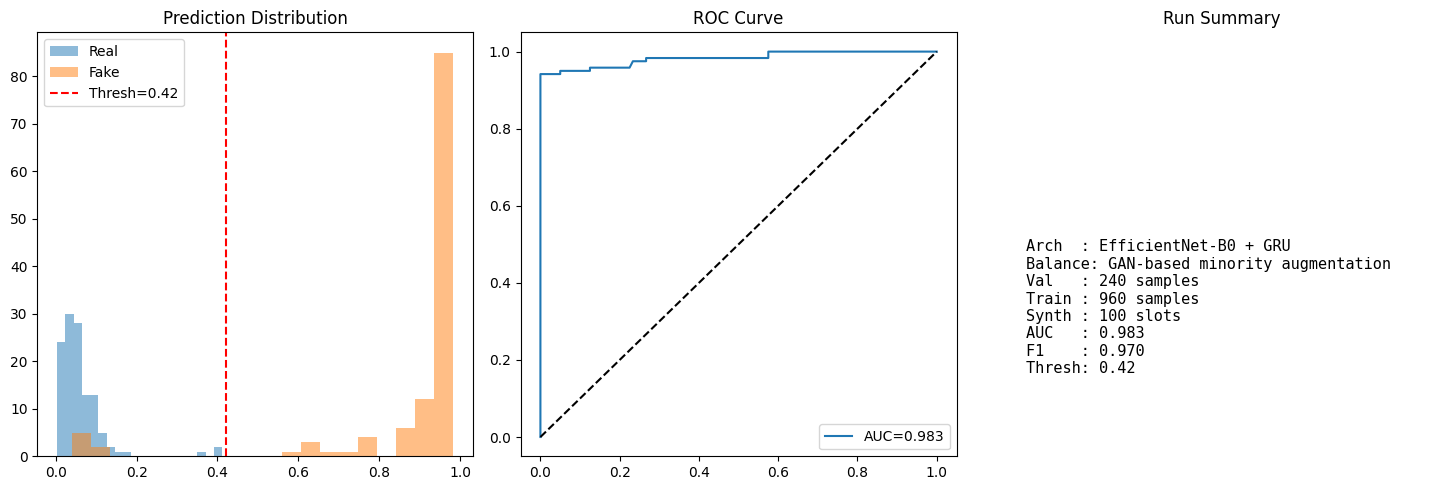


COMPLETE! Saved: /kaggle/working/best_model_efficientnet_gan_balancing.pth  |  /kaggle/working/results_efficientnet_gan_balancing.png


In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.hist(all_probs[all_labels_eval == 0], alpha=0.5, label="Real", bins=20)
plt.hist(all_probs[all_labels_eval == 1], alpha=0.5, label="Fake", bins=20)
plt.axvline(best_thresh, color="red", linestyle="--", label=f"Thresh={best_thresh:.2f}")
plt.legend(); plt.title("Prediction Distribution")

plt.subplot(132)
fpr, tpr, _ = roc_curve(all_labels_eval, all_probs)
plt.plot(fpr, tpr, label=f'AUC={final_metrics["AUC"]:.3f}')
plt.plot([0, 1], [0, 1], "k--"); plt.legend(); plt.title("ROC Curve")

plt.subplot(133)
summary = (f"Arch  : EfficientNet-B0 + GRU\n"
           f"Balance: {BALANCING_NAME}\n"
           f"Val   : {VAL_SIZE} samples\n"
           f"Train : {len(train_paths)} samples\n"
           f"Synth : {augmented_count} slots\n"
           f"AUC   : {final_metrics['AUC']:.3f}\n"
           f"F1    : {final_metrics['F1_Score']:.3f}\n"
           f"Thresh: {best_thresh:.2f}")
plt.text(0.05, 0.35, summary, fontsize=11, verticalalignment="center",
         fontfamily="monospace")
plt.axis("off"); plt.title("Run Summary")

plt.tight_layout()
plt.savefig(f"/kaggle/working/results_{RESULT_TAG}.png", dpi=150)
plt.show()
print(f"\nCOMPLETE! Saved: /kaggle/working/best_model_{RESULT_TAG}.pth  |  /kaggle/working/results_{RESULT_TAG}.png")
